In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, vstack
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [22]:
books = pd.read_csv('Books.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False)
ratings = pd.read_csv('Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip')
users = pd.read_csv('Users.csv', sep=';', encoding='latin-1', on_bad_lines='skip')

# Стандартизуем имена колонок (зависит от версии датасета)
books.columns = [c.strip().replace('"','') for c in books.columns]
ratings.columns = [c.strip().replace('"','') for c in ratings.columns]
print("Сырые размеры:")
print(f"  Ratings: {ratings.shape}")
print(f"  Books:   {books.shape}")
print(f"  Users:   {users.shape}\n")


Сырые размеры:
  Ratings: (1149780, 3)
  Books:   (271379, 5)
  Users:   (278859, 2)



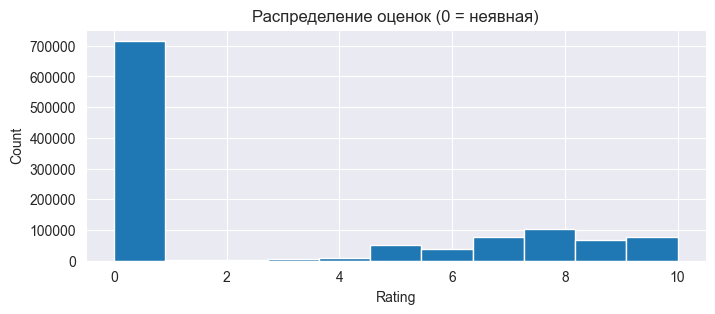

Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

После фильтрации:
  Оценок: 61398
  Юзеров: 4242
  Книг:   3147
  Sparsity: 0.9954


In [23]:
# --- EDA: распределение оценок ---
plt.figure(figsize=(8,3))
ratings['Rating'].hist(bins=11)
plt.title('Распределение оценок (0 = неявная)')
plt.xlabel('Rating'); plt.ylabel('Count')
plt.show()
print(ratings['Rating'].value_counts().sort_index())

# --- Только явные оценки ---
ratings = ratings[ratings['Rating'] > 0].copy()

# --- Чистим мусорные ISBN ---
ratings = ratings[ratings['ISBN'].str.match(r'^[\dX]+$', na=False)]
books   = books[books['ISBN'].str.match(r'^[\dX]+$', na=False)]
ratings = ratings[ratings['ISBN'].isin(books['ISBN'])]

# --- Sparsity-фильтр ---
u_cnt = ratings['User-ID'].value_counts()
b_cnt = ratings['ISBN'].value_counts()
ratings = ratings[ratings['User-ID'].isin(u_cnt[u_cnt >= 15].index)]
ratings = ratings[ratings['ISBN'].isin(b_cnt[b_cnt >= 15].index)]
books   = books[books['ISBN'].isin(ratings['ISBN'].unique())].reset_index(drop=True)

n_u, n_b = ratings['User-ID'].nunique(), ratings['ISBN'].nunique()
print(f"\nПосле фильтрации:")
print(f"  Оценок: {len(ratings)}")
print(f"  Юзеров: {n_u}")
print(f"  Книг:   {n_b}")
print(f"  Sparsity: {1 - len(ratings)/(n_u*n_b):.4f}")

In [24]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

user_ids = ratings['User-ID'].unique()
book_ids = ratings['ISBN'].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
book2idx = {b: i for i, b in enumerate(book_ids)}
idx2book = {i: b for b, i in book2idx.items()}
n_users, n_books = len(user_ids), len(book_ids)
print(f"n_users={n_users}, n_books={n_books}")

n_users=4242, n_books=3147


In [25]:
def evaluate(recommend_fn, test_df, k=10, n_users_eval=300, name=""):
    relevant = defaultdict(set)
    for _, r in test_df[test_df['Rating'] >= 7].iterrows():
        relevant[r['User-ID']].add(r['ISBN'])

    eval_users = [u for u in relevant if u in user2idx][:n_users_eval]
    P, R, H, AP, NDCG = [], [], [], [], []

    for u in eval_users:
        recs = recommend_fn(u, top_n=k)
        if not recs: 
            continue
        rel = relevant[u]
        hits = [1 if rr in rel else 0 for rr in recs]
        hit = sum(hits)

        P.append(hit/k)
        R.append(hit/len(rel))
        H.append(1 if hit > 0 else 0)

        ap, cum = 0, 0
        for i, h in enumerate(hits):
            if h:
                cum += 1
                ap += cum/(i+1)
        AP.append(ap/min(len(rel), k))

        dcg  = sum(h/np.log2(i+2) for i, h in enumerate(hits))
        idcg = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
        NDCG.append(dcg/idcg if idcg else 0)

    return {'Model': name,
            f'Precision@{k}': round(np.mean(P), 4),
            f'Recall@{k}':    round(np.mean(R), 4),
            f'HitRate@{k}':   round(np.mean(H), 4),
            f'MAP@{k}':       round(np.mean(AP), 4),
            f'NDCG@{k}':      round(np.mean(NDCG), 4)}

def show_books(isbns, limit=10):
    return books[books['ISBN'].isin(isbns)][['ISBN','Title','Author']].head(limit)

In [26]:
print("="*60); print("SVD"); print("="*60)

row = train['User-ID'].map(user2idx).values
col = train['ISBN'].map(book2idx).values
data = train['Rating'].values.astype(float)
R_dense = csr_matrix((data, (row, col)), shape=(n_users, n_books)).toarray()

mask = R_dense > 0
user_means = R_dense.sum(axis=1) / np.maximum(mask.sum(axis=1), 1)
R_centered = R_dense - user_means[:, None]*mask

def fit_svd(k):
    U, s, Vt = svds(R_centered, k=k)
    return U @ np.diag(s) @ Vt + user_means[:, None]

svd_grid, preds_cache = [], {}
for k in [10, 20, 50, 100, 150]:
    pred = fit_svd(k)
    preds_cache[k] = pred
    def rec(uid, top_n=10, _p=pred):
        if uid not in user2idx: return []
        ui = user2idx[uid]
        s = _p[ui].copy(); s[R_dense[ui]>0] = -np.inf
        return [idx2book[i] for i in np.argsort(-s)[:top_n]]
    res = evaluate(rec, test, name=f"SVD k={k}")
    svd_grid.append(res); print(res)

print("\n", pd.DataFrame(svd_grid))

best_k = 50
pred_svd = preds_cache[best_k]

def recommend_svd(uid, top_n=10):
    if uid not in user2idx: return []
    ui = user2idx[uid]
    s = pred_svd[ui].copy(); s[R_dense[ui]>0] = -np.inf
    return [idx2book[i] for i in np.argsort(-s)[:top_n]]

# Демо
sample_user = train['User-ID'].value_counts().index[5]
print(f"\n=== Демо для юзера {sample_user} ===")
liked = train[(train['User-ID']==sample_user) & (train['Rating']>=8)]['ISBN'].tolist()
print("Любимое:");  print(show_books(liked))
print("\nSVD рекомендует:"); print(show_books(recommend_svd(sample_user)))

SVD
{'Model': 'SVD k=10', 'Precision@10': np.float64(0.009), 'Recall@10': np.float64(0.0121), 'HitRate@10': np.float64(0.0867), 'MAP@10': np.float64(0.004), 'NDCG@10': np.float64(0.0117)}
{'Model': 'SVD k=20', 'Precision@10': np.float64(0.013), 'Recall@10': np.float64(0.0177), 'HitRate@10': np.float64(0.1133), 'MAP@10': np.float64(0.0066), 'NDCG@10': np.float64(0.0171)}
{'Model': 'SVD k=50', 'Precision@10': np.float64(0.0113), 'Recall@10': np.float64(0.016), 'HitRate@10': np.float64(0.1), 'MAP@10': np.float64(0.0067), 'NDCG@10': np.float64(0.0164)}
{'Model': 'SVD k=100', 'Precision@10': np.float64(0.0093), 'Recall@10': np.float64(0.0132), 'HitRate@10': np.float64(0.0833), 'MAP@10': np.float64(0.004), 'NDCG@10': np.float64(0.0117)}
{'Model': 'SVD k=150', 'Precision@10': np.float64(0.0097), 'Recall@10': np.float64(0.016), 'HitRate@10': np.float64(0.0933), 'MAP@10': np.float64(0.0071), 'NDCG@10': np.float64(0.0159)}

        Model  Precision@10  Recall@10  HitRate@10  MAP@10  NDCG@10
0   

In [27]:
print("="*60); print("CONTENT-BASED"); print("="*60)

books['Title']     = books['Title'].fillna('').astype(str)
books['Author']    = books['Author'].fillna('').astype(str)
books['Publisher'] = books['Publisher'].fillna('').astype(str)
books['content']   = books['Title']+' '+books['Author']+' '+books['Publisher']

tfidf = TfidfVectorizer(stop_words='english', max_features=10000,
                        ngram_range=(1,2), min_df=2)
tfidf_matrix = tfidf.fit_transform(books['content'])
print("TF-IDF shape:", tfidf_matrix.shape)

book_isbns = books['ISBN'].values
isbn2tfidf = {isbn: i for i, isbn in enumerate(book_isbns)}

def build_user_profile(uid):
    ur = train[train['User-ID']==uid]
    vecs, w = [], []
    for _, r in ur.iterrows():
        if r['ISBN'] in isbn2tfidf:
            vecs.append(tfidf_matrix[isbn2tfidf[r['ISBN']]])
            w.append(r['Rating'])
    if not vecs: return None, set()
    profile = vstack(vecs).multiply(np.array(w)[:, None]).sum(axis=0)/sum(w)
    return np.asarray(profile), set(ur['ISBN'])

def recommend_content(uid, top_n=10):
    profile, seen = build_user_profile(uid)
    if profile is None: return []
    sims = cosine_similarity(profile, tfidf_matrix).flatten()
    cands = [(book_isbns[i], sims[i]) for i in range(len(sims))
             if book_isbns[i] not in seen]
    cands.sort(key=lambda x: -x[1])
    return [c[0] for c in cands[:top_n]]

# Эксперименты с гиперпараметрами TF-IDF
content_grid = []
for mf, ng in [(5000,(1,1)), (10000,(1,2)), (20000,(1,2))]:
    tv = TfidfVectorizer(stop_words='english', max_features=mf,
                         ngram_range=ng, min_df=2)
    mat = tv.fit_transform(books['content'])
    def rec(uid, top_n=10, _mat=mat):
        ur = train[train['User-ID']==uid]
        vecs, w = [], []
        for _, r in ur.iterrows():
            if r['ISBN'] in isbn2tfidf:
                vecs.append(_mat[isbn2tfidf[r['ISBN']]])
                w.append(r['Rating'])
        if not vecs: return []
        prof = vstack(vecs).multiply(np.array(w)[:,None]).sum(axis=0)/sum(w)
        sims = cosine_similarity(np.asarray(prof), _mat).flatten()
        seen = set(ur['ISBN'])
        cands = [(book_isbns[i], sims[i]) for i in range(len(sims))
                 if book_isbns[i] not in seen]
        cands.sort(key=lambda x: -x[1])
        return [c[0] for c in cands[:top_n]]
    res = evaluate(rec, test, name=f"Content mf={mf} ng={ng}")
    content_grid.append(res); print(res)

print("\n", pd.DataFrame(content_grid))

print("\nContent рекомендует:")
print(show_books(recommend_content(sample_user)))

CONTENT-BASED
TF-IDF shape: (3147, 5120)
{'Model': 'Content mf=5000 ng=(1, 1)', 'Precision@10': np.float64(0.0502), 'Recall@10': np.float64(0.0947), 'HitRate@10': np.float64(0.3232), 'MAP@10': np.float64(0.0427), 'NDCG@10': np.float64(0.0805)}
{'Model': 'Content mf=10000 ng=(1, 2)', 'Precision@10': np.float64(0.0525), 'Recall@10': np.float64(0.1001), 'HitRate@10': np.float64(0.3232), 'MAP@10': np.float64(0.0487), 'NDCG@10': np.float64(0.0876)}
{'Model': 'Content mf=20000 ng=(1, 2)', 'Precision@10': np.float64(0.0525), 'Recall@10': np.float64(0.1001), 'HitRate@10': np.float64(0.3232), 'MAP@10': np.float64(0.0487), 'NDCG@10': np.float64(0.0876)}

                         Model  Precision@10  Recall@10  HitRate@10  MAP@10  \
0   Content mf=5000 ng=(1, 1)        0.0502     0.0947      0.3232  0.0427   
1  Content mf=10000 ng=(1, 2)        0.0525     0.1001      0.3232  0.0487   
2  Content mf=20000 ng=(1, 2)        0.0525     0.1001      0.3232  0.0487   

   NDCG@10  
0   0.0805  
1   0.0

In [28]:
print("="*60); print("HYBRID"); print("="*60)

def recommend_hybrid(uid, top_n=10, alpha=0.5, n_candidates=100):
    user_train = train[train['User-ID']==uid]
    # Cold-start branch
    if len(user_train) < 5 or uid not in user2idx:
        return recommend_content(uid, top_n)

    ui = user2idx[uid]
    s = pred_svd[ui].copy(); s[R_dense[ui]>0] = -np.inf
    cand_idx = np.argsort(-s)[:n_candidates]
    cand_isbns = [idx2book[i] for i in cand_idx]
    svd_cand = s[cand_idx]
    svd_norm = (svd_cand - svd_cand.min())/(svd_cand.ptp()+1e-9)

    profile, _ = build_user_profile(uid)
    if profile is None:
        return cand_isbns[:top_n]
    rows = [isbn2tfidf[i] for i in cand_isbns if i in isbn2tfidf]
    if not rows: return cand_isbns[:top_n]
    cand_mat = tfidf_matrix[rows]
    cs = cosine_similarity(profile, cand_mat).flatten()
    cs_norm = (cs - cs.min())/(cs.ptp()+1e-9)

    final = alpha*svd_norm[:len(cs_norm)] + (1-alpha)*cs_norm
    order = np.argsort(-final)
    return [cand_isbns[i] for i in order[:top_n]]

hyb_grid = []
for a in [0.2, 0.4, 0.5, 0.6, 0.8]:
    r = evaluate(lambda u, top_n=10, _a=a: recommend_hybrid(u, top_n, alpha=_a),
                 test, name=f"Hybrid α={a}")
    hyb_grid.append(r); print(r)
print("\n", pd.DataFrame(hyb_grid))

print("\nHybrid рекомендует:")
print(show_books(recommend_hybrid(sample_user)))

HYBRID


AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

In [18]:
print("="*60); print("LINUCB BANDIT"); print("="*60)

reducer = TruncatedSVD(n_components=30, random_state=42)
book_emb = reducer.fit_transform(tfidf_matrix)
isbn2emb = {isbn: book_emb[isbn2tfidf[isbn]]
            for isbn in book_isbns if isbn in isbn2tfidf}

class LinUCB:
    def __init__(self, d, alpha=0.7):
        self.A = np.eye(d); self.b = np.zeros(d); self.alpha = alpha
    def score(self, X):
        Ainv = np.linalg.inv(self.A)
        th = Ainv @ self.b
        mean = X @ th
        ucb = self.alpha*np.sqrt(np.einsum('ij,jk,ik->i', X, Ainv, X))
        return mean + ucb
    def update(self, x, r):
        self.A += np.outer(x, x); self.b += r*x

def make_recommend_bandit(alpha=0.7):
    cache = {}
    def rec(uid, top_n=10):
        if uid not in cache:
            b = LinUCB(30, alpha=alpha)
            for _, r in train[train['User-ID']==uid].iterrows():
                if r['ISBN'] in isbn2emb:
                    rew = 1.0 if r['Rating'] >= 7 else 0.0
                    b.update(isbn2emb[r['ISBN']], rew)
            cache[uid] = b
        seen = set(train[train['User-ID']==uid]['ISBN'])
        cands = [i for i in book_isbns if i not in seen and i in isbn2emb]
        X = np.array([isbn2emb[c] for c in cands])
        sc = cache[uid].score(X)
        return [cands[i] for i in np.argsort(-sc)[:top_n]]
    return rec

# Эксперименты с alpha (exploration)
bandit_grid = []
for a in [0.1, 0.5, 1.0, 2.0]:
    rec_fn = make_recommend_bandit(alpha=a)
    r = evaluate(rec_fn, test, name=f"LinUCB α={a}")
    bandit_grid.append(r); print(r)
print("\n", pd.DataFrame(bandit_grid))

recommend_bandit = make_recommend_bandit(alpha=0.7)
print("\nLinUCB рекомендует:")
print(show_books(recommend_bandit(sample_user)))

LINUCB BANDIT
{'Model': 'LinUCB α=0.1', 'Precision@10': np.float64(0.0527), 'Recall@10': np.float64(0.1014), 'HitRate@10': np.float64(0.3433), 'MAP@10': np.float64(0.0484), 'NDCG@10': np.float64(0.0892)}
{'Model': 'LinUCB α=0.5', 'Precision@10': np.float64(0.0503), 'Recall@10': np.float64(0.0964), 'HitRate@10': np.float64(0.33), 'MAP@10': np.float64(0.0425), 'NDCG@10': np.float64(0.0813)}
{'Model': 'LinUCB α=1.0', 'Precision@10': np.float64(0.0347), 'Recall@10': np.float64(0.0722), 'HitRate@10': np.float64(0.27), 'MAP@10': np.float64(0.0296), 'NDCG@10': np.float64(0.0596)}
{'Model': 'LinUCB α=2.0', 'Precision@10': np.float64(0.007), 'Recall@10': np.float64(0.0109), 'HitRate@10': np.float64(0.0667), 'MAP@10': np.float64(0.0034), 'NDCG@10': np.float64(0.0093)}

           Model  Precision@10  Recall@10  HitRate@10  MAP@10  NDCG@10
0  LinUCB α=0.1        0.0527     0.1014      0.3433  0.0484   0.0892
1  LinUCB α=0.5        0.0503     0.0964      0.3300  0.0425   0.0813
2  LinUCB α=1.0    

In [20]:
print("="*60); print("ИТОГИ"); print("="*60)

final = []
final.append(evaluate(recommend_svd,     test, name="SVD (k=50)"))
final.append(evaluate(recommend_content, test, name="Content TF-IDF"))
final.append(evaluate(recommend_hybrid,  test, name="Hybrid (α=0.5)"))
final.append(evaluate(recommend_bandit,  test, name="LinUCB (α=0.7)"))

final_df = pd.DataFrame(final).set_index('Model')
print(final_df)

final_df.plot(kind='bar', figsize=(12,5))
plt.title('Сравнение моделей: BookCrossing')
plt.ylabel('Score'); plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

ИТОГИ


AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.